# Boston Housing Violations — Data Visualizations

This notebook produces all preliminary visualizations for the CS506 final project.
It reads from `merged_violations.csv` generated by `data_processing.ipynb`.

**Three Project Goals:**
- **Goal 1:** Identify owners/companies with the highest violation frequencies
- **Goal 2:** Determine if building characteristics (age, type, condition) correlate with violations
- **Goal 3:** Categorize and quantify the most prevalent types of housing complaints

## Setup & Data Loading

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# ── Global style ────────────────────────────────────────────────────────────
plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'figure.dpi': 120,
})
ACCENT = '#2a6db5'   # primary blue
WARN   = '#e05c2a'   # orange-red for highlights

df = pd.read_csv('merged_violations.csv')
print(f'Dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} columns')
df.head(3)

Dataset loaded: 17,075 rows × 24 columns


,case_no,status_dttm,status,code,description,violation_stno,violation_street,violation_city,violation_zip,ward,...,PARCEL,POINT_X,POINT_Y,OWNER,YR_BUILT,LU,LU_DESC,BLDG_TYPE,OWN_OCC,OVERALL_COND
0,V91983,NaN,Closed,121.2,Unsafe and Dangerous,302,Sumner,East Boston,2128.0,1,...,104910000.0,-71.036580,42.367679,ORELLANA-SERRANO ISRAEL,1930.0,R3,THREE-FAM DWELLING,RM - Row Middle,Y,A - Average
1,V898855,2026-03-25 10:13:31,Open,105.1,Failure to Obtain Permit,335,Harrison,Roxbury,2118.0,3,...,306337000.0,-71.064197,42.345034,345 HARRISON LLC,2016.0,RC,RES /COMMERCIAL USE,120 - LUXURY APARTMENT,N,EX - Excellent
2,V898828,2026-03-25 09:20:39,Open,105.1,Failure to Obtain Permit,217,Albany,Roxbury,2118.0,3,...,306626000.0,-71.061720,42.345440,217 ALBANY II LLC,2020.0,A,LUXURY APARTMENT,114 - APT 100+ UNITS,N,VG - Very Good


---
## Visualization 1 — Top 10 Violation Types
Categorize the most prevalent types of housing complaints.

**Why this chart?**  
A horizontal bar chart lets us rank many text categories cleanly. By sorting and labeling each bar we immediately surface which violation types demand the most city resources.

**Key finding:**  
"Failure to Obtain Permit" (4,181) and "Unsafe and Dangerous" (3,611) together account for nearly half of all violations — pointing to both regulatory non-compliance and genuine structural safety risks.

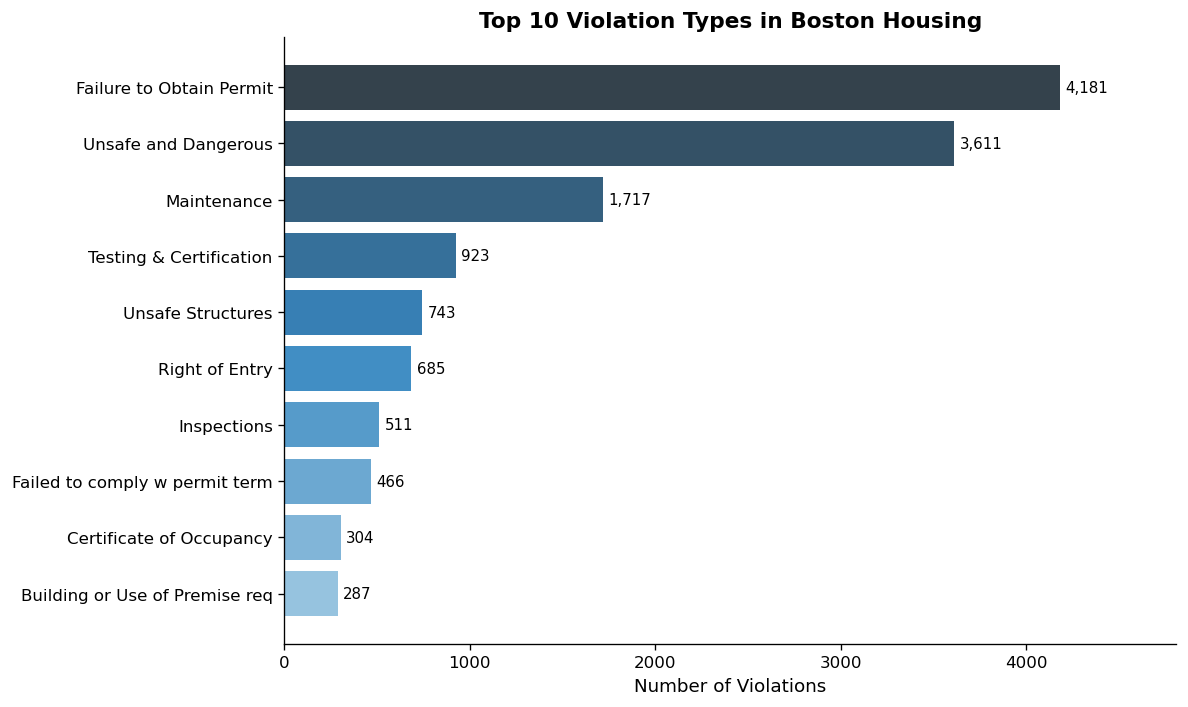

In [3]:
top_desc = df['description'].value_counts().head(10)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(
    top_desc.index[::-1], top_desc.values[::-1],
    color=sns.color_palette('Blues_d', 10)
)
for bar, val in zip(bars, top_desc.values[::-1]):
    ax.text(
        bar.get_width() + 30, bar.get_y() + bar.get_height() / 2,
        f'{val:,}', va='center', fontsize=9
    )
ax.set_xlabel('Number of Violations', fontsize=11)
ax.set_title('Top 10 Violation Types in Boston Housing', fontsize=13, fontweight='bold')
ax.set_xlim(0, top_desc.values.max() * 1.15)
plt.tight_layout()
plt.savefig('viz1_top_violation_types.png', bbox_inches='tight', dpi=150)
plt.show()

---
## Visualization 2 — Violations by Neighborhood
Where are the problems concentrated, and how many?

**Why this chart?**  
A bar chart ranked by count immediately shows which neighborhoods bear the most violations. Highlighting the top bar draws attention to the outlier.

**Key finding:**  
Dorchester leads with 4,526 violations — nearly 1.7× the second-highest area. East Boston, Roxbury, and Mattapan also stand out, all historically dense residential neighborhoods with older housing stock.

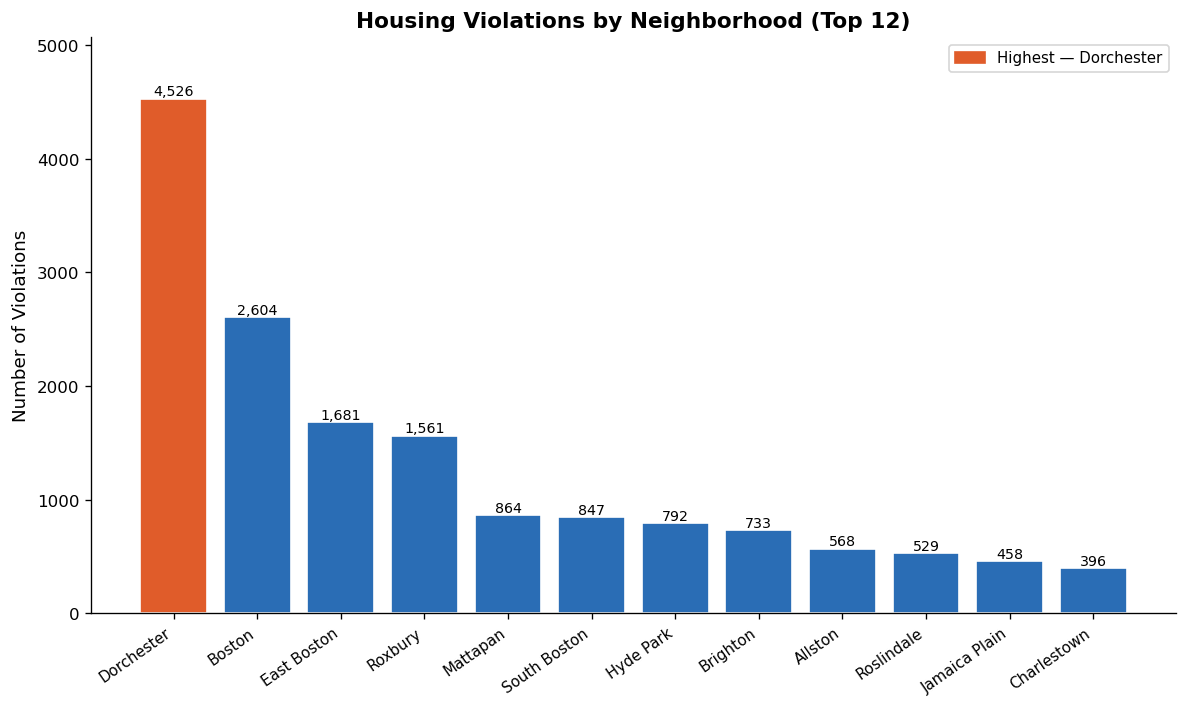

In [4]:
neigh = df['MAILING_NEIGHBORHOOD'].value_counts().dropna().head(12)

fig, ax = plt.subplots(figsize=(10, 6))
colors = [WARN if n == neigh.index[0] else ACCENT for n in neigh.index]
bars = ax.bar(neigh.index, neigh.values, color=colors, edgecolor='white')
for bar, val in zip(bars, neigh.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2, bar.get_height() + 30,
        f'{val:,}', ha='center', fontsize=8.5
    )
ax.set_ylabel('Number of Violations', fontsize=11)
ax.set_title('Housing Violations by Neighborhood (Top 12)', fontsize=13, fontweight='bold')
plt.xticks(rotation=35, ha='right', fontsize=9)
ax.set_ylim(0, neigh.values.max() * 1.12)
red_patch = mpatches.Patch(color=WARN, label='Highest — Dorchester')
ax.legend(handles=[red_patch], fontsize=9)
plt.tight_layout()
plt.savefig('viz2_violations_by_neighborhood.png', bbox_inches='tight', dpi=150)
plt.show()

---
## Visualization 3 — Violations by Property / Land-Use Type
Do building characteristics correlate with violation rates?

**Why this chart?**  
Land-use type is a key building characteristic. A horizontal bar chart handles long category names well and makes the ranking immediately legible.

**Key finding:**  
Three-family dwellings (3,242) and condos (2,951) lead — multi-tenant buildings amplify the impact of landlord non-compliance because more residents are affected per violation.

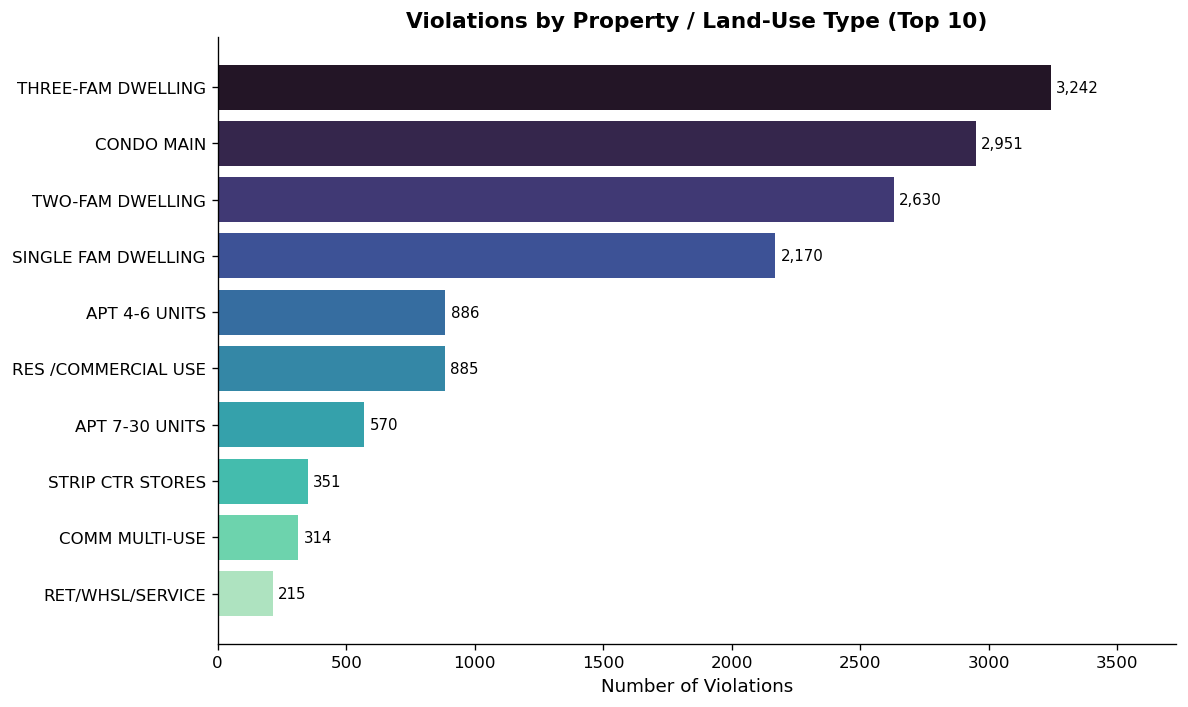

In [5]:
lu = df['LU_DESC'].value_counts().head(10).sort_values()

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(lu.index, lu.values, color=sns.color_palette('mako_r', len(lu)))
for bar, val in zip(bars, lu.values):
    ax.text(
        bar.get_width() + 20, bar.get_y() + bar.get_height() / 2,
        f'{val:,}', va='center', fontsize=9
    )
ax.set_xlabel('Number of Violations', fontsize=11)
ax.set_title('Violations by Property / Land-Use Type (Top 10)', fontsize=13, fontweight='bold')
ax.set_xlim(0, lu.values.max() * 1.15)
plt.tight_layout()
plt.savefig('viz3_violations_by_property_type.png', bbox_inches='tight', dpi=150)
plt.show()

---
## Visualization 4 — Year Built Distribution
Is building age associated with higher violation rates?

**Why this chart?**  
A histogram is the natural choice for a continuous variable like construction year. The median reference line provides a concrete anchor without cluttering the chart.

**Key finding:**  
The distribution is heavily skewed — median build year is **1910**, meaning the typical violating property is over 115 years old. Age is a strong candidate predictor for our model.

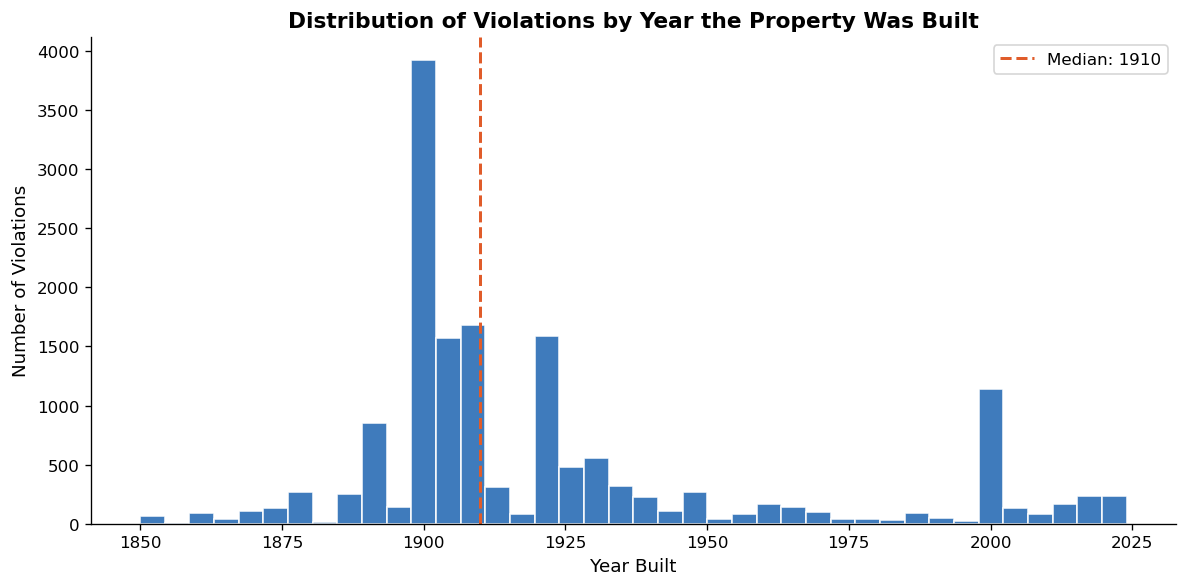

In [6]:
yr = df['YR_BUILT'].dropna()
yr = yr[(yr >= 1850) & (yr <= 2025)]   # drop implausible outliers
median_yr = int(yr.median())

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(yr, bins=40, color=ACCENT, edgecolor='white', alpha=0.9)
ax.axvline(median_yr, color=WARN, linestyle='--', linewidth=1.8,
           label=f'Median: {median_yr}')
ax.set_xlabel('Year Built', fontsize=11)
ax.set_ylabel('Number of Violations', fontsize=11)
ax.set_title('Distribution of Violations by Year the Property Was Built',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('viz4_year_built_distribution.png', bbox_inches='tight', dpi=150)
plt.show()

---
## Visualization 5 — Top 15 Private Owners by Violation Count
Identify the most prolific repeat offenders.

**Why this chart?**  
This is the most direct answer to Goal 1. Government entities (City of Boston, BHA) are excluded because they manage public housing under different accountability structures — including them would distort the private landlord analysis.

**Key finding:**  
A small set of LLCs and limited partnerships are repeat offenders. The top private violator has 43 cases — city inspectors could achieve outsized compliance gains by targeting these owners specifically.

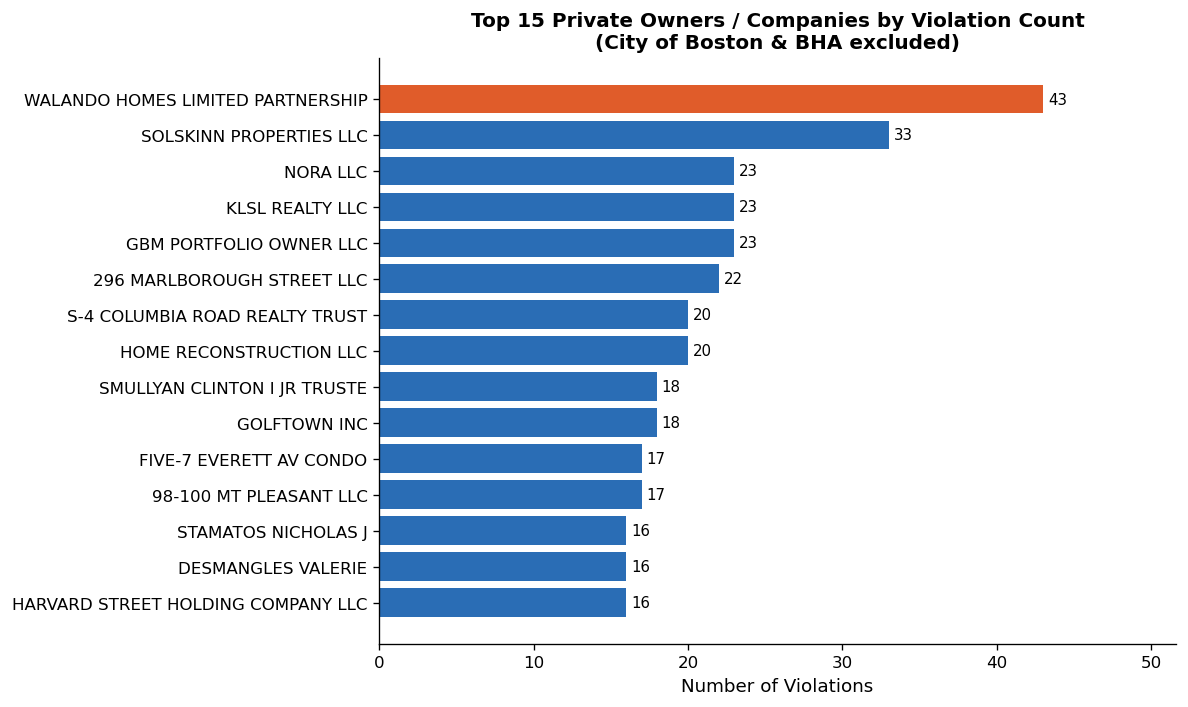

In [7]:
EXCLUDE = ['CITY OF BOSTON', 'BOSTON HOUSING AUTHORITY']
owners = (
    df[~df['OWNER'].isin(EXCLUDE)]['OWNER']
    .value_counts()
    .head(15)
)

fig, ax = plt.subplots(figsize=(10, 6))
colors = [WARN if i == 0 else ACCENT for i in range(len(owners))]
bars = ax.barh(owners.index[::-1], owners.values[::-1], color=colors[::-1])
for bar, val in zip(bars, owners.values[::-1]):
    ax.text(
        bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
        str(val), va='center', fontsize=9
    )
ax.set_xlabel('Number of Violations', fontsize=11)
ax.set_title(
    'Top 15 Private Owners / Companies by Violation Count\n'
    '(City of Boston & BHA excluded)',
    fontsize=12, fontweight='bold'
)
ax.set_xlim(0, owners.values.max() * 1.2)
plt.tight_layout()
plt.savefig('viz5_top_owners.png', bbox_inches='tight', dpi=150)
plt.show()

---
## Visualization 6 — Open vs. Closed Violations by Neighborhood
Which neighborhoods have the most unresolved violations?

**Why this chart?**  
A 100% stacked bar chart normalizes for neighborhood size, so we compare *resolution rates* rather than raw counts. Sorting by % Open surfaces the neighborhoods with the most persistent unresolved issues.

**Key finding:**  
Citywide, ~94% of violations are closed. Some neighborhoods show a slightly higher proportion of still-open cases, which may reflect more recent filings or slower enforcement response.

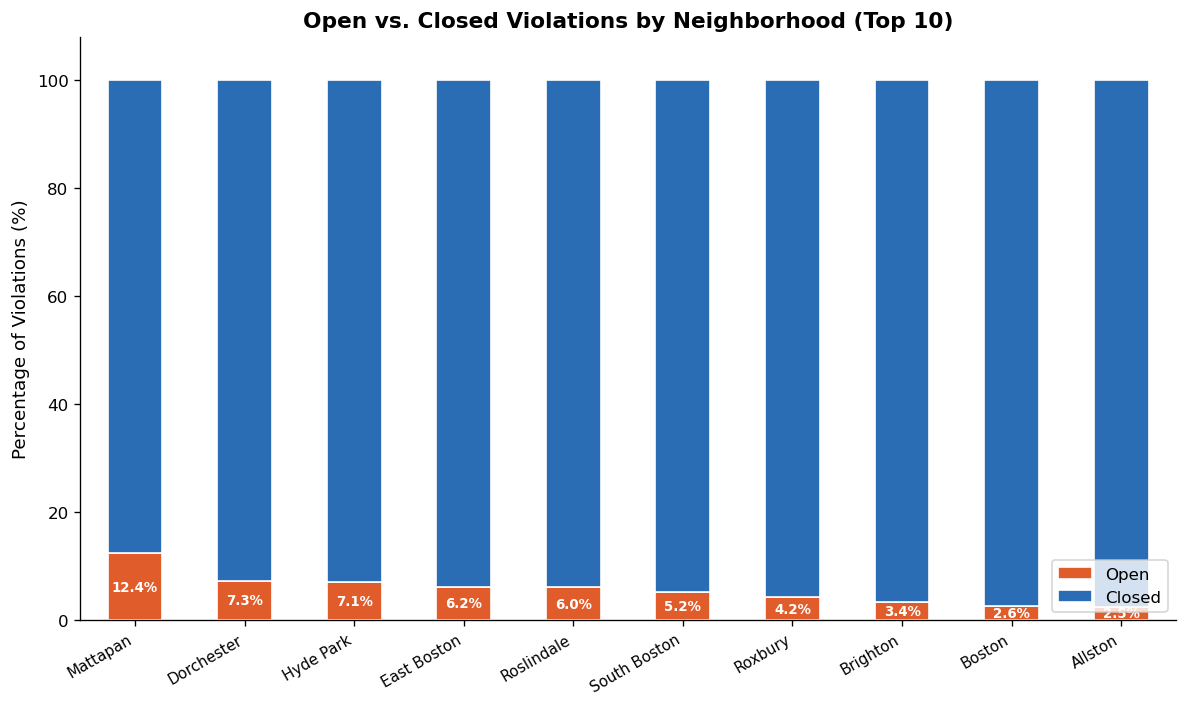

In [8]:
top10_neigh = df['MAILING_NEIGHBORHOOD'].value_counts().head(10).index
sub = df[df['MAILING_NEIGHBORHOOD'].isin(top10_neigh)]

status_ct = (
    sub.groupby(['MAILING_NEIGHBORHOOD', 'status'])
    .size()
    .unstack(fill_value=0)
)
status_pct = status_ct.div(status_ct.sum(axis=1), axis=0) * 100
status_pct = status_pct.sort_values('Open', ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
status_pct[['Open', 'Closed']].plot(
    kind='bar', stacked=True, ax=ax,
    color=[WARN, ACCENT], edgecolor='white'
)
ax.set_ylabel('Percentage of Violations (%)', fontsize=11)
ax.set_xlabel('')
ax.set_title(
    'Open vs. Closed Violations by Neighborhood (Top 10)',
    fontsize=13, fontweight='bold'
)
plt.xticks(rotation=30, ha='right', fontsize=9)
ax.legend(['Open', 'Closed'], loc='lower right', fontsize=10)
ax.set_ylim(0, 108)
# Label the Open % inside each bar
for i, (idx, row) in enumerate(status_pct.iterrows()):
    open_pct = row.get('Open', 0)
    if open_pct > 2:
        ax.text(i, open_pct / 2, f'{open_pct:.1f}%',
                ha='center', va='center', fontsize=8,
                color='white', fontweight='bold')
plt.tight_layout()
plt.savefig('viz6_open_closed_by_neighborhood.png', bbox_inches='tight', dpi=150)
plt.show()

---
## Visualization 7 — Overall Building Condition
Does assessed building condition correlate with violation rate?

**Why this chart?**  
A color-coded bar chart ordered from worst to best condition gives an intuitive gradient. It tests the assumption that "violations = bad building."

**Key finding:**  
Most violations occur in buildings rated "Average" or "Good" — not "Poor." Permit and certification lapses can happen in any building regardless of structural condition, so overall condition alone is not a strong standalone predictor.

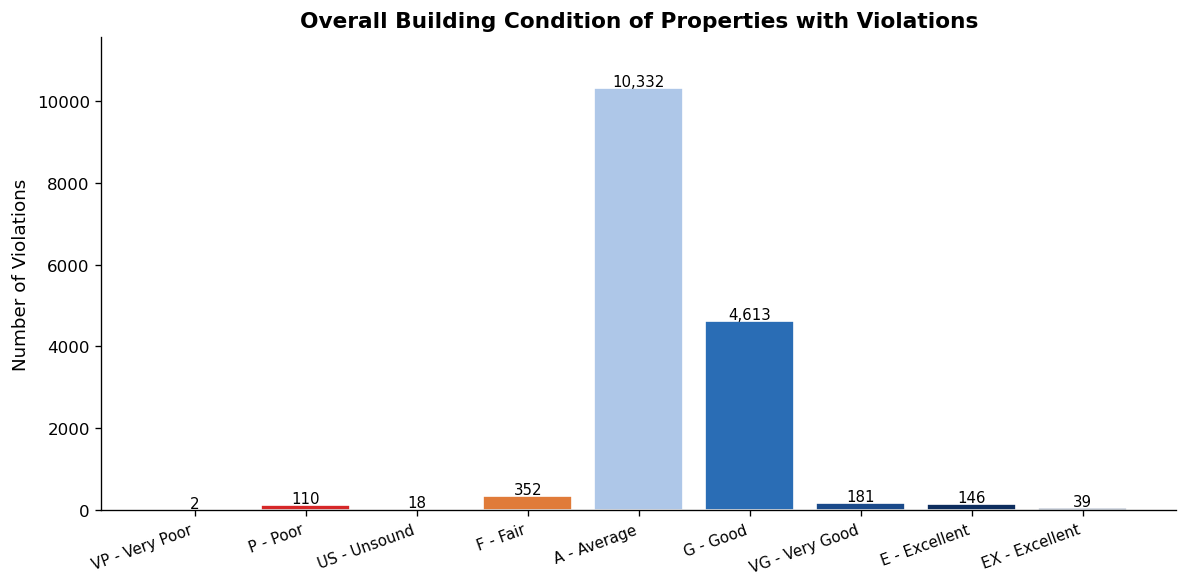

In [9]:
COND_ORDER = [
    'VP - Very Poor', 'P - Poor', 'US - Unsound', 'F - Fair',
    'A - Average', 'G - Good', 'VG - Very Good',
    'E - Excellent', 'EX - Excellent'
]
COND_COLORS = [
    '#d62728', '#d62728', '#d62728', '#e07b39',
    '#aec7e8', '#2a6db5', '#1a4a8a', '#0d2d5e', '#0d2d5e'
]

present = [c for c in COND_ORDER if c in df['OVERALL_COND'].unique()]
cond = df['OVERALL_COND'].value_counts().reindex(present, fill_value=0)
colors = COND_COLORS[:len(cond)]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(cond.index, cond.values, color=colors, edgecolor='white')
for bar, val in zip(bars, cond.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2, bar.get_height() + 50,
        f'{val:,}', ha='center', fontsize=9
    )
ax.set_ylabel('Number of Violations', fontsize=11)
ax.set_title('Overall Building Condition of Properties with Violations',
             fontsize=13, fontweight='bold')
plt.xticks(rotation=20, ha='right', fontsize=9)
ax.set_ylim(0, cond.values.max() * 1.12)
plt.tight_layout()
plt.savefig('viz7_overall_condition.png', bbox_inches='tight', dpi=150)
plt.show()

---
## Visualization 8 — Geographic Distribution (Dot Map)
Where are violations spatially concentrated?

**Why this chart?**  
A geographic scatter plot is the most intuitive way to show spatial distribution. Open violations (orange, larger, opaque) are layered on top of closed ones (blue, small, transparent) so the unresolved cases stand out without losing overall context.

**Key finding:**  
Dense clusters appear in Dorchester and East Boston, which is consistent with Visualization 2. Open violations are distributed citywide, suggesting enforcement response is not geographically biased.

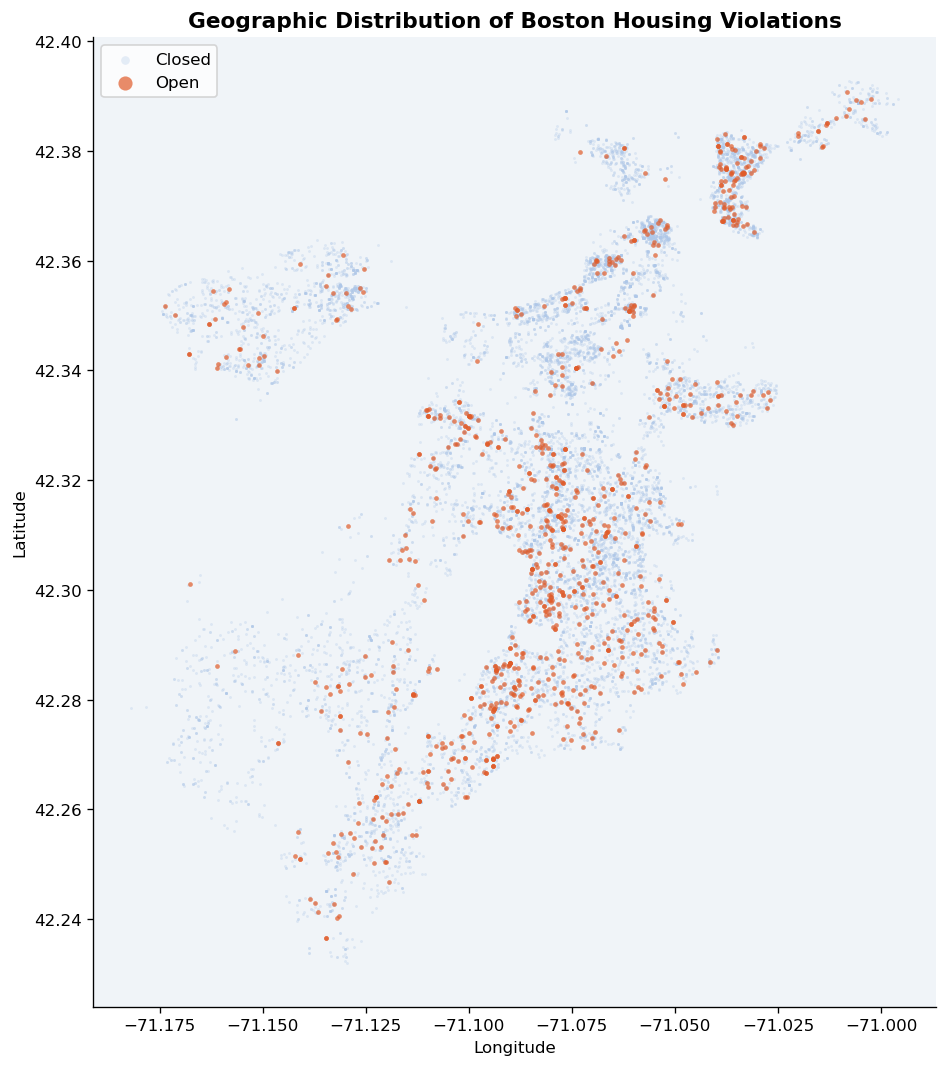

In [10]:
geo = df.dropna(subset=['latitude', 'longitude'])

fig, ax = plt.subplots(figsize=(8, 9))
# Draw closed violations first (background layer)
for status, color, size, alpha, label in [
        ('Closed', '#aec7e8', 3,  0.30, 'Closed'),
        ('Open',   WARN,      8,  0.70, 'Open')]:
    sub = geo[geo['status'] == status]
    ax.scatter(
        sub['longitude'], sub['latitude'],
        c=color, s=size, alpha=alpha, label=label, linewidths=0
    )
ax.set_xlabel('Longitude', fontsize=10)
ax.set_ylabel('Latitude', fontsize=10)
ax.set_title('Geographic Distribution of Boston Housing Violations',
             fontsize=13, fontweight='bold')
ax.legend(markerscale=3, fontsize=10)
ax.set_facecolor('#f0f4f8')
plt.tight_layout()
plt.savefig('viz8_geographic_scatter.png', bbox_inches='tight', dpi=150)
plt.show()